<h1 align="center"><b>Bone Mineral Density Prediction Challenge - Semester 01, 2026</b></h1>
<h2 align="center">CSG2341 Artificial Intelligence 1</h2>
<h3 align="center">Lecturer: Mr. Niroshan Balasuriya</h3>
<h3 align="center">Group: NIR-01</h3>
<h4 align="center">Anuki Senanayakalage (Student ID 10712258)</h4>
<h4 align="center">Disara Ambagala (Student ID 10745176)</h4>
<h4 align="center">Shivangi Sritharan (Student ID 10712234)</h4>
<br>

---
add a real intro/description here i'm lazy

---
<h2><b>Notebook Structure</b></h2>
<table style="display: block; margin-right: auto;">
  <tr><th>#</th><th>Section</th></tr>
  <tr><td>1</td><td><a href="#1---Imports">Imports</a></td></tr>
  <tr><td>2</td><td><a href="#2---File-Paths">File Paths</a></td></tr>
  <tr><td>3</td><td><a href="#3---Load-Metadata">Load Metadata</a></td></tr>
  <tr><td>4</td><td><a href="#4---Organise-Images-into-Folders">Organise Images into Folders</a></td></tr>
  <tr><td>5</td><td><a href="#5---Exploratory-Data-Analysis">Exploratory Data Analysis</a></td></tr>
  <tr><td>6</td><td><a href="#6---Pre-processing-Pipeline">Pre-processing Pipeline</a></td></tr>
  <tr><td>7</td><td><a href="#7---Combine-Image-Features-and-Metadata">Combine Image Features and Metadata</a></td></tr>
  <tr><td>8</td><td><a href="#8---Pipeline-Scaling">Pipeline Scaling</a></td></tr>
  <tr><td>9</td><td><a href="#9---Regression-Evaluation">Regression Evaluation</a></td></tr>
  <tr><td>10</td><td><a href="#10---Diagnostic-Plots">Diagnostic Plots</a></td></tr>
  <tr><td>11</td><td><a href="#11---Convert-Predicted-BMD">Convert Predicted BMD</a></td></tr>
  <tr><td>12</td><td><a href="#12---Evaluation">Evaluation</a></td></tr>
</table>

# 1 - Imports

This section is used to set up the libraries needed to run our notebook.

We first import standard Python modules such as `os` and `pathlib` for file handling. We then import data processing libraries such as `numpy` and `pandas` as well as data visualization libraries such as `matplotlib` to support exploratory data analysis.

For image processing, the code uses `cv2` (OpenCV) along with `skimage` functions such as Histogram of Oriented Gradients (HOG). These are used to extract meaningful features from image data and aid in pre-processing the images.

The machine learning pipeline is built using `scikit-learn`. We import preprocessing tools such as `StandardScaler` and `LabelEncoder`, modules for dimensionality reduction, and modeling with Support Vector Regression. Model selection and evaluation are supported with `GridSearchCV` and `KFold` for cross-validation. Additionally, performance metrics such as MAE, MSE, R², confusion matrix, and classification reports are imported.

Finally, some configuration settings are applied. Warnings are suppressed for cleaner output, and Matplotlib and Seaborn are configured to create visually consistent plots. We also set a fixed random seed to ensure reproducibility across runs.

In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform # for loguniform
import math

# Image I/O and feature extraction
import cv2
from skimage.feature import hog
from skimage.measure import moments_hu, moments_central, moments_normalized, moments
from skimage import filters, morphology, measure
from skimage.feature import graycomatrix, graycoprops
from scipy import stats

# Modelling
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, balanced_accuracy_score, classification_report
)

#import warnings
#warnings.filterwarnings("ignore")

# Same seed everywhere
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
%matplotlib inline

<br>

# 2 - File Paths

This section defines all the directory paths and global constants used throughout the notebook.

- `IMAGE_DIR` is the root folder containing all X-ray image data.
- `TRAIN_CSV` and `VAL_CSV` are constants for the train and val CSV files provided with the dataset.
- `TRAIN_IMAGE_DIR` and `VAL_IMAGE_DIR` are the destination folders for images that will be populated in Section 4.
- `IMG_SIZE` - every image is resized to this square resolution before feature extraction.
- `HIST_BINS` is the number of bins used when computing a grayscale intensity histogram.

**Please edit the three paths at the top of the code cell to match your local folder layout before running anything else.**

In [3]:
# ============ Please modify these 3 values according to your folder structure. ============

IMAGE_DIR  = Path("X-rays") # folder path for images
TRAIN_CSV  = Path("train_groundtruth_BMD.csv") # path for the training metadata csv
VAL_CSV    = Path("val_groundtruth_BMD.csv") # path for the validation metadata csv


# This code looks for folders named train_images and val_images and builds them if they don't exist.
TRAIN_IMAGE_DIR = Path("train_images")
VAL_IMAGE_DIR   = Path("val_images")

# Image and feature settings
IMG_SIZE = 128                # resize images to 128x128
HIST_BINS = 64                # grayscale histogram bins

# T-score reference
REF_BMD = 0.86
REF_SD  = 0.12

# Checks if the files exist
assert TRAIN_CSV.exists(), "Training CSV not found"
assert VAL_CSV.exists(), "Validation CSV not found"
assert IMAGE_DIR.exists(), "Image folder not found"

<br>

# 3 - Load Metadata

The two CSV files containing metadata for training and validation datasets are read into pandas DataFrames. Each CSV file includes the image filename, the target BMD value and patient related information.

After loading the files, the first few rows and columns are printed to confirm that data has been imported correctly.

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

# Checks dimensions and columns
print(f"Train: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Val:   {val_df.shape[0]} rows, {val_df.shape[1]} columns")
train_df.head()

Train: 377 rows, 4 columns
Val:   54 rows, 4 columns


,image,interview_age,Gender,BMD
0,6.E.1_9021102_20090706_001.png,888,F,0.696443
1,6.E.1_9030718_20090824_001.png,960,F,1.201649
2,6.E.1_9047519_20090720_001.png,876,F,0.945649
3,6.C.1_9048789_20090226_001.png,780,F,0.927137
4,6.E.1_9054972_20090911_001.png,828,F,0.987368


# 4 - Organise Images into Folders

The dataset was provided to us with all the images in one directory named "X-rays". For better visualisation, we decided to separate out the images into dedicated folders based on how they will be used in the pipeline. This section copies each image into a dedicated `train_images/` or `val_images/` subdirectory based on the split recorded in the metadata CSV files.

**Please run this cell ONCE. On subsequent runs, comment out the cell to avoid additional disk operations.**

In [5]:
# Uncomment and run once to organise images into train and val folders
# Then comment this block again.

import shutil

def organise_split(source_dir, dest_dir, df):
    dest_dir.mkdir(exist_ok=True)

    for filename in df["image"]:
        src = source_dir / filename
        dst = dest_dir / filename

        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)


organise_split(IMAGE_DIR, TRAIN_IMAGE_DIR, train_df)
organise_split(IMAGE_DIR, VAL_IMAGE_DIR, val_df)

print("Image folders organised.")

Image folders organised.


# 5 - Exploratory Data Analysis

In this section, we will analyze metadata from the data that was used for the training process. The dataset under consideration contains information about 250 people who have their age (in months), gender and Bone Mineral Density values recorded. Visualization techniques are going to be applied for investigating the mentioned characteristics of our dataset, including gender distribution, BMD distribution, class balance between Normal and Low BMD patiens, and the relationship between age and BMD values.

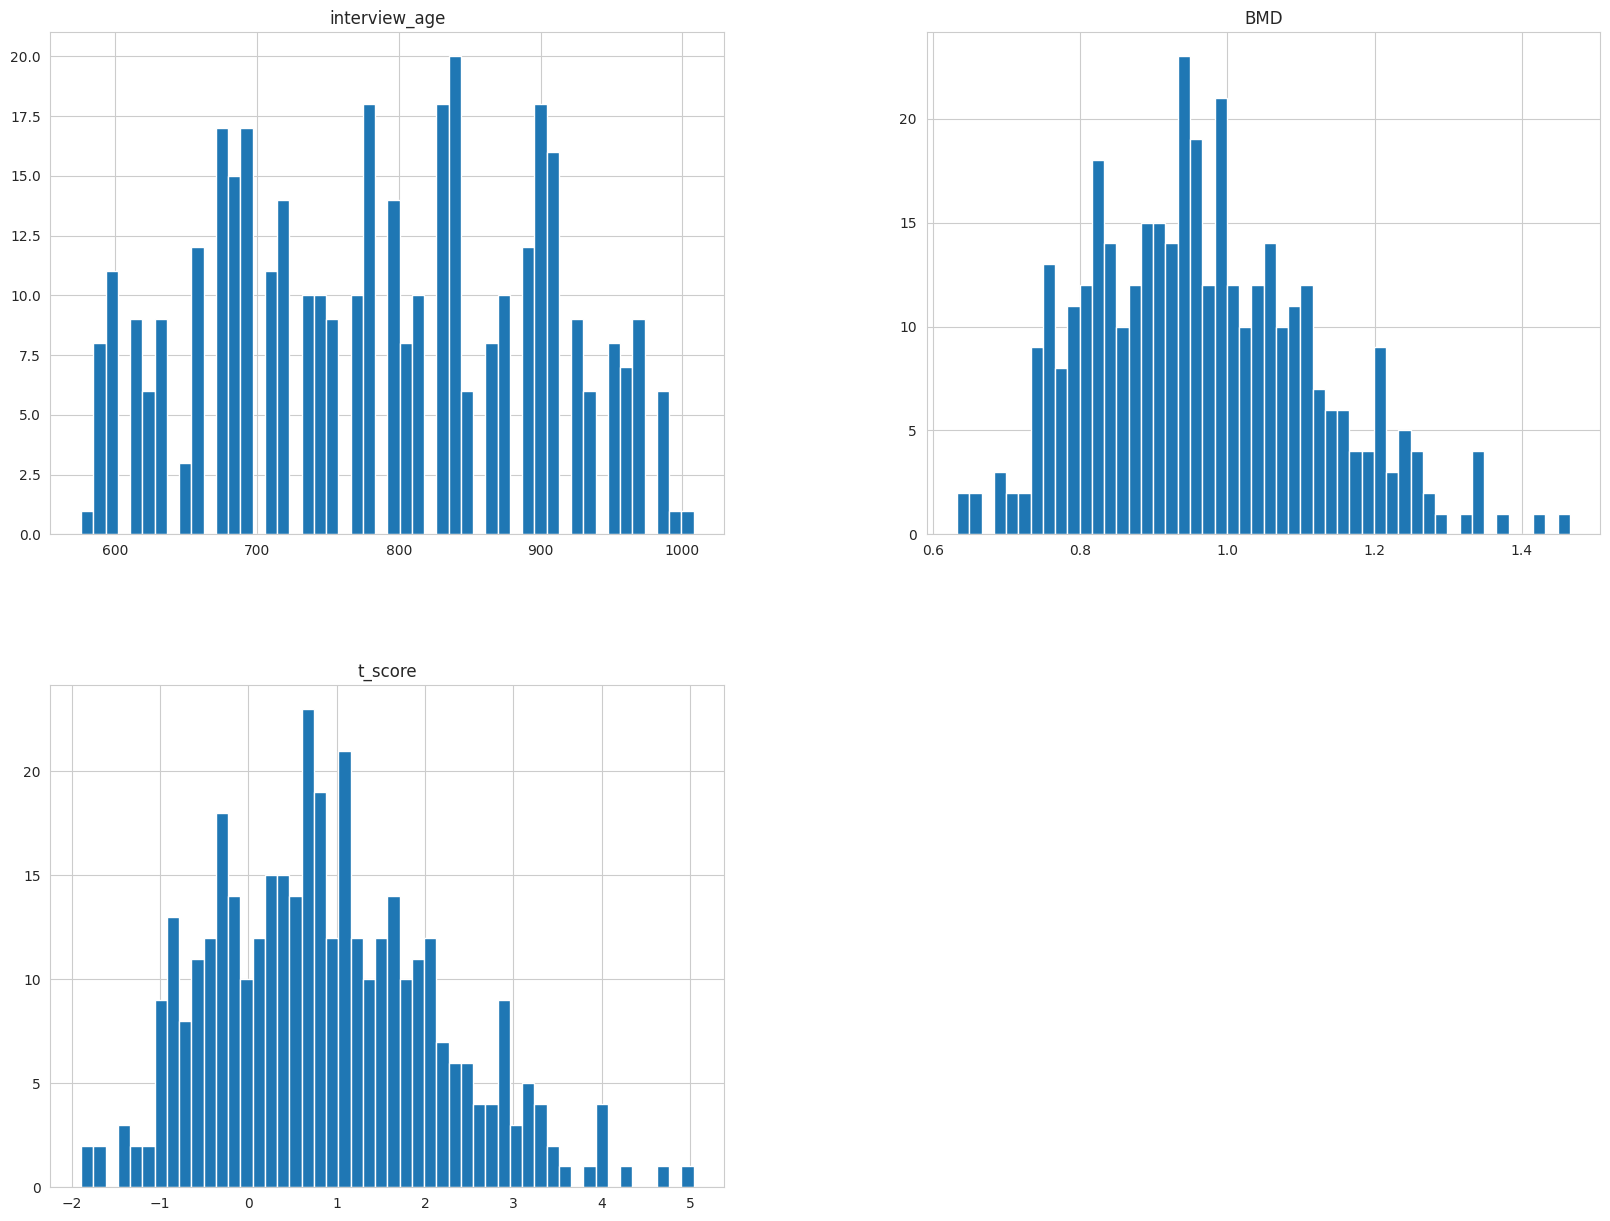

In [6]:


# add T-score column
train_df["t_score"], val_df["t_score"] = (train_df["BMD"] - 0.86)/0.12, (val_df["BMD"] - 0.86)/0.12

# add binary label (0 = Normal, 1 = Low BMD)
train_df["low_bmd"], val_df["low_bmd"] = (train_df["t_score"] < -1), (val_df["t_score"] < -1)

train_df.head()

# use Pandas' hist() method to plot the histograms of each numerical column vs number of entries
# you can modify the bins and figsize, and also look up more arguments for the method
train_df.hist(bins=50, figsize=(20,15))

# actually display the plot
plt.show()

<br>

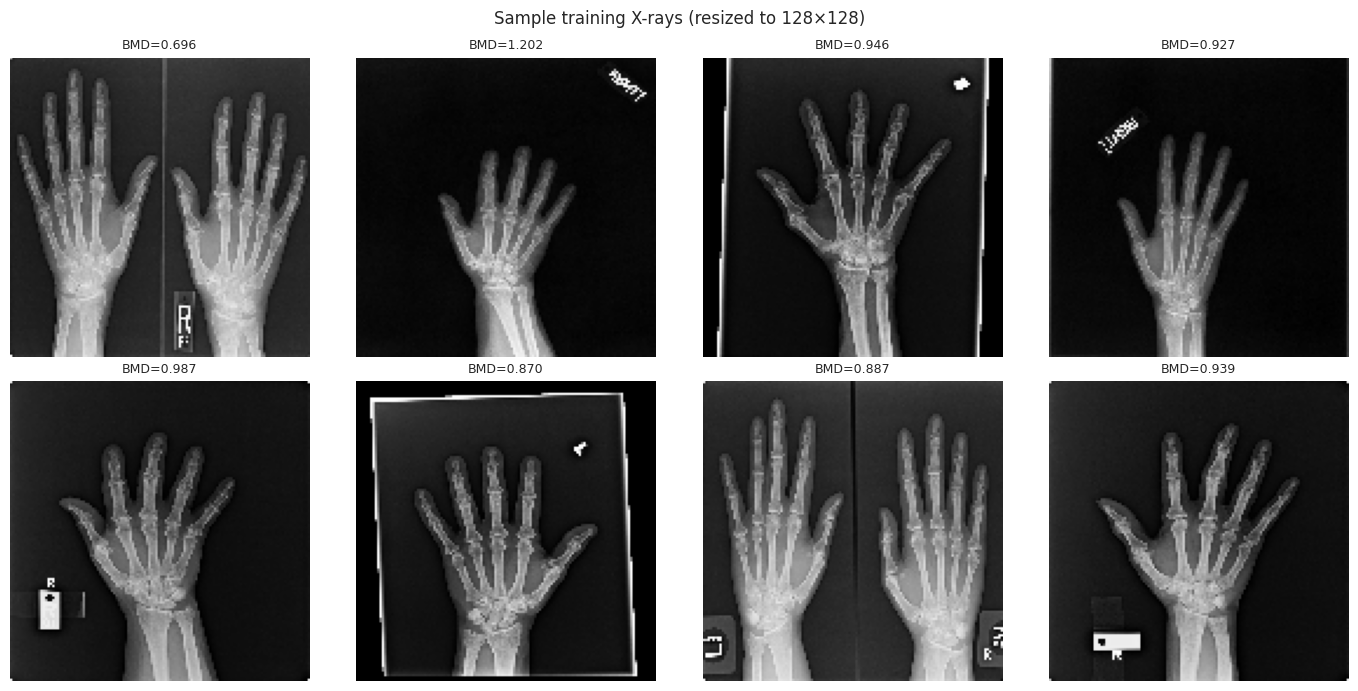

In [7]:


# display the first 8 training images so we can confirm they loaded correctly

# train_df.head() is the first x rows of the data frame named train_df.
# head() usually defaults to 5 but we set 8 here
sample_rows = train_df.head(8)

# creates a 2x4 grid of 8 subplots (2 rows, 4 columns)
# and sets the figure size to 14x7
# you can change 2, 4 and the values in figsize (14, 7) to see what happens
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# iterate simultaneously through the grid set up with plt.subplots and the data frame in sample_rows
for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    # create path to the image by combining the training folder name and the name of the image as defined in the csv
    img_path = TRAIN_IMAGE_DIR / row["image"]

    if img_path.exists():
        # look for the image defined by img_path
        # you can also look for other arguments to add here, such as cv2.IMREAD_GRAYSCALE (google it lol)
        img = cv2.imread(str(img_path))
        # resize image to the size set in Section 2
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # pair it with a subplot
        # you can also look for other arguments to add here, such as cmap (google it lol)
        ax.imshow(img)
        # give the subplot a title (we just display its BMD value but you can set it to the image name or whatever you'd like)
        ax.set_title(f"BMD={row['BMD']:.3f}", fontsize=9)

    # display this if no image is found. you can display the plot without an if/else loop but if any errors occur it will stop the whole notebook
    else:
        ax.set_title("Warning: Image not found!", color="red", fontsize=9)

    # hides the grid components. you can comment this out or delete it to see what happens
    ax.axis("off")

# give the plot a title
plt.suptitle("Sample training X-rays (resized to 128×128)", fontsize=12)

# adjust padding so the subplots automatically fit into the space instead of overflowing or overlapping
# you can remove or comment this out to see what happens.
plt.tight_layout()

# actually display the plot
plt.show()

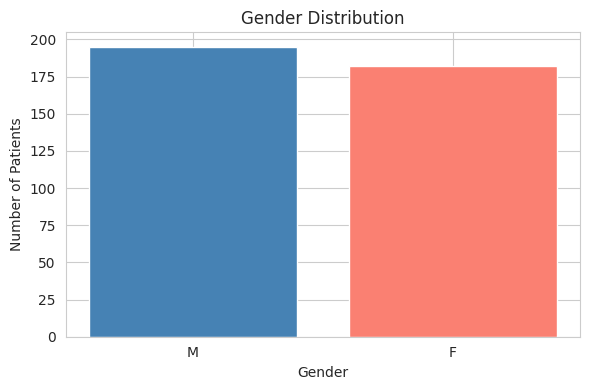

In [8]:
# [Disara] Gender distribution of training data
gender_counts = train_df['Gender'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values, color=['steelblue','salmon'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

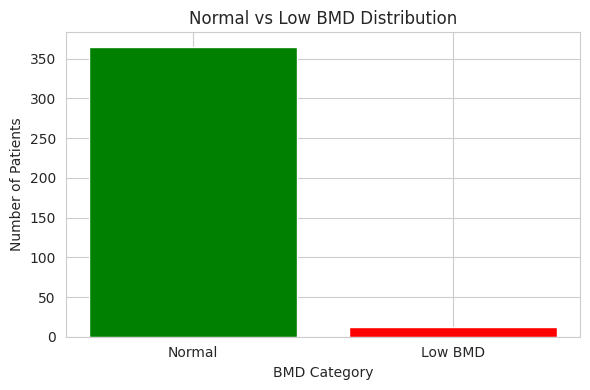

In [9]:
# [Disara] Class distribution - Normal vs Low BMD
bmd_counts = train_df['low_bmd'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(['Normal','Low BMD'], bmd_counts.values, color=['green','red'])
plt.title('Normal vs Low BMD Distribution')
plt.xlabel('BMD Category')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

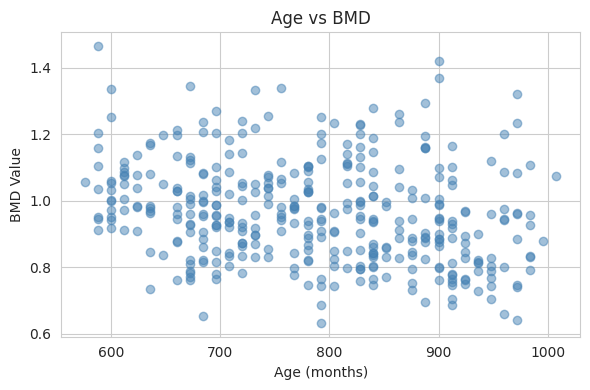

In [10]:
# [Disara] Relationship between age and BMD
plt.figure(figsize=(6,4))
plt.scatter(train_df['interview_age'], train_df['BMD'], alpha=0.5, color='steelblue')
plt.title('Age vs BMD')
plt.xlabel('Age (months)')
plt.ylabel('BMD Value')
plt.tight_layout()
plt.show()

# 6 - Pre-processing Pipeline

<h2 style="color: red;">PIPELINE IS UNFINISHED !!!</h2>

First, we do a quick check to make sure there is no overlap between train and validation sets. This ensures no data leakage has occurred at this stage.

In [11]:
overlap = train_df["image"].isin(val_df["image"])

if overlap.any():
    print(f"Image overlap found: {overlap.sum()} IDs")
else:
    print("No overlap")

No overlap


In [12]:
# This is a reusable helper function to load images.

def load_image(image_dir: Path, filename: str):
    img_path = image_dir / filename
    if img_path.exists():
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE) # load in greyscale
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LANCZOS4) # use this bc it's the highest quality downscaler
    # print dummy if image is missing
    else:
        print(f"Warning: {filename} not found!")
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    return img

In [13]:
def plot_images(image_dir: Path, df: pd.DataFrame):
    images = []

    for filename in df["image"]:
        # reuse the helper function instead of duplicating logic
        img = load_image(image_dir, filename)

        images.append(img)

        # plot for visual inspection
        plt.figure()
        plt.imshow(img, cmap="gray") # matplotlib otherwise defaults to viridis, which isn't helpful for us
        plt.title(filename)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return images

In [14]:
#imgs = plot_images(TRAIN_IMAGE_DIR, train_df)

In [15]:
# This function checks if the pixels in an image a below a certain threshold and inverts the image if they are.
# Basically, it just checks if an image is primarily white and flips it to primarily black.

# https://www.medrxiv.org/content/10.1101/2022.02.03.22270400v1.full.pdf

def auto_invert(img: np.ndarray, white_ratio_thresh=0.5):
    white_ratio = img.mean() / 255.0
    if white_ratio > white_ratio_thresh:
        img = cv2.bitwise_not(img)
    return img

In [16]:
# Other images are barely visible, so we turn up the contrast.
# We use CLAHE to boost the contrast.
# clahe = contrast limited adaptive histogram equalization
# it divides the image into smaller parts and adjust the contrast in each part separately

def contrast_fix(img):
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    return clahe.apply(img)

# This checks for low pixel variation (ie images that are mostly black)
def fix_low_variation(img: np.ndarray, low_std_thresh=10):
    std = img.std()
    if std < low_std_thresh:
        img = contrast_fix(img)
    return img

In [17]:
# normalize values

def normalize_percentile(img, lower=1, upper=99):
    lo = np.percentile(img, lower)
    hi = np.percentile(img, upper)

    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8) * 255
    return img.astype(np.uint8)

In [18]:
def preprocess_image(img: np.ndarray) -> np.ndarray:
    # auto invert if mostly white
    img = auto_invert(img)
    # normalize pixel data
    img = normalize_percentile(img)
    # fix contrast
    img = contrast_fix(img)

    return img


def load_and_preprocess(image_dir: Path, filename: str):
    img_path = image_dir / filename

    if img_path.exists():
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LANCZOS4) # use this bc it's the highest quality downscaler
    else:
        print(f"Warning: {filename} not found!")
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    return preprocess_image(img)


def plot_images(image_dir: Path, df: pd.DataFrame):
    images = []

    filenames = df["image"].tolist()
    n = len(filenames)

    # decide grid size
    cols = 5
    rows = math.ceil(n / cols)

    #fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    #axes = np.array(axes).reshape(-1)

    for i, filename in enumerate(filenames):
        img = load_and_preprocess(image_dir, filename)
        images.append(img)

        # show progress updates every 25 images
        if (i + 1) % 25 == 0 or (i + 1) == n:
            print(f"Processed {i + 1}/{n} images...")

        if (i + 1) == n:
            print("Now creating image plots, please wait...")

    return images
'''
        ax = axes[i]
        ax.imshow(img, cmap="gray")
        ax.set_title(filename, fontsize=8)
        ax.axis("off")

    # turn off unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return images
'''

'\n        ax = axes[i]\n        ax.imshow(img, cmap="gray")\n        ax.set_title(filename, fontsize=8)\n        ax.axis("off")\n\n    # turn off unused subplots\n    for j in range(i + 1, len(axes)):\n        axes[j].axis("off")\n\n    plt.tight_layout()\n    plt.show()\n\n    return images\n'

In [19]:
processed_train_images = plot_images(TRAIN_IMAGE_DIR, train_df)

Processed 25/377 images...
Processed 50/377 images...
Processed 75/377 images...
Processed 100/377 images...
Processed 125/377 images...
Processed 150/377 images...
Processed 175/377 images...
Processed 200/377 images...
Processed 225/377 images...
Processed 250/377 images...
Processed 275/377 images...
Processed 300/377 images...
Processed 325/377 images...
Processed 350/377 images...
Processed 375/377 images...
Processed 377/377 images...
Now creating image plots, please wait...


We can see that some images responded badly to the normalization (ie. they appear as black x-rays on a white background). Because of the time constraints, we elected to remove these as well as one dramatically rotated image.

In [20]:
rm_files = ["6.E.1_9049223_20090720_001.png", "6.C.1_9735403_20080825_001.png", "6.C.1_9785684_20081007_001.png", "6.C.1_9659956_20080925_001.png"]

train_df = train_df[~train_df["image"].isin(rm_files)]

In [21]:
processed_val_images = plot_images(VAL_IMAGE_DIR, val_df)

Processed 25/54 images...
Processed 50/54 images...
Processed 54/54 images...
Now creating image plots, please wait...


In [22]:
def extract_histogram_statistics(img: np.ndarray) -> np.ndarray:
    """
    Computes 8 global descriptors from the pixel intensity distribution.

    Called after preprocess_image() so values are already normalised to [0,255]
    and contrast-enhanced. These statistics are rotation/translation-invariant,
    which suits X-rays where patient positioning varies between scans.

    Returns
    -------
    np.ndarray, shape (8,)
        [mean, std, variance, skewness, kurtosis, energy, entropy, p95–p5 range]
    """
    px = img.flatten().astype(np.float64)

    mean      = np.mean(px)
    std       = np.std(px)
    variance  = np.var(px)
    skewness  = float(stats.skew(px))
    kurt      = float(stats.kurtosis(px))

    # Build histogram over the full [0,255] range using the global HIST_BINS constant
    hist, _   = np.histogram(px, bins=HIST_BINS, range=(0, 255), density=True)

    # Energy (uniformity): high when intensity distribution is very peaked
    energy    = np.sum(hist ** 2)

    # Entropy: measures complexity/randomness of the distribution
    entropy   = -np.sum(hist * np.log2(hist + 1e-10))    # +eps avoids log(0)

    # Percentile range: robust spread measure, ignores extreme outlier pixels
    perc_range = np.percentile(px, 95) - np.percentile(px, 5)

    return np.array([mean, std, variance, skewness, kurt,
                     energy, entropy, perc_range], dtype=np.float32)

In [23]:
def _segment_bone(img: np.ndarray) -> np.ndarray:
    """
    Produces a binary mask isolating the dominant bone structure.

    Steps:
      1. Otsu threshold — separates bright bone from soft tissue/background.
      2. Morphological closing (disk radius 5) — fills small intra-bone gaps
         that would otherwise create spurious concavities in shape measures.
      3. Largest connected component — discards small artefacts or
         secondary structures so shape descriptors target the primary bone.
    """
    thresh  = filters.threshold_otsu(img)
    binary  = img > thresh
    binary  = morphology.closing(binary, morphology.disk(5))

    labeled = measure.label(binary)
    props   = measure.regionprops(labeled)

    if not props:
        return binary                              # fallback: raw threshold mask

    largest = max(props, key=lambda r: r.area)
    return labeled == largest.label


def extract_shape_features(img: np.ndarray) -> np.ndarray:
    """
    Derives 9 geometric descriptors from the segmented bone mask.

    These capture morphological anomalies such as cortical erosion, fractures,
    or deformities that pure intensity features cannot detect.

    Returns
    -------
    np.ndarray, shape (9,)
        [area, perimeter, eccentricity, solidity, extent,
         major_axis_length, minor_axis_length, axis_ratio, compactness]
    """
    mask = _segment_bone(img)

    # regionprops needs a labelled integer array, not a bool mask
    rp = measure.regionprops(mask.astype(np.uint8))[0]

    area         = rp.area
    perimeter    = rp.perimeter + 1e-6             # epsilon prevents /0 below

    # Eccentricity: 0 = perfect circle, 1 = line — detects elongated deformities
    eccentricity = rp.eccentricity

    # Solidity: area / convex-hull area — drops sharply when bone has concavities
    solidity     = rp.solidity

    # Extent: area / bounding-box area — low for irregular outlines
    extent       = rp.extent

    major_ax     = rp.axis_major_length
    minor_ax     = rp.axis_minor_length

    # Axis ratio: quantifies elongation while avoiding division-by-zero
    axis_ratio   = major_ax / (minor_ax + 1e-6)

    # Compactness (circularity): 4π·A / P²  →  1.0 for a perfect circle
    compactness  = (4 * np.pi * area) / (perimeter ** 2)

    return np.array([area, perimeter, eccentricity, solidity, extent,
                     major_ax, minor_ax, axis_ratio, compactness],
                    dtype=np.float32)

In [24]:
def extract_glcm_features(
    img: np.ndarray,
    distances: list = [1, 3],
    angles: list    = [0, np.pi/4, np.pi/2, 3*np.pi/4]
) -> np.ndarray:
    """
    Computes Haralick texture descriptors from the Gray Level Co-occurrence Matrix.

    Multiple distances and angles are used so the features are approximately
    isotropic — important because trabecular patterns appear at various
    orientations. Both the mean and range across all (distance, angle) pairs
    are returned; the range captures directional anisotropy in bone texture.

    Quantised to 64 grey levels to reduce GLCM sparsity at the 128×128
    image resolution set in IMG_SIZE.
    """
    levels = 64
    # Quantise: map [0,255] → [0, levels-1] so GLCM bins stay dense
    img_q  = (img / 255.0 * (levels - 1)).astype(np.uint8)

    glcm   = graycomatrix(
        img_q,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,   # symmetric → direction of offset is ignored
        normed=True       # normalised → entries are joint probabilities
    )

    def _stat(prop):
        """Mean and range across all (distance, angle) combinations."""
        vals = graycoprops(glcm, prop).ravel()   # shape: (n_dist × n_angles,)
        return vals.mean(), vals.max() - vals.min()

    # Contrast:      local intensity variation (high in noisy / heterogeneous regions)
    # Dissimilarity: linear version of contrast
    # Homogeneity:   high when GLCM is concentrated near the main diagonal
    # Energy (ASM):  sum of squared entries — high for very regular textures
    # Correlation:   linear dependency between neighbouring pixel intensities
    contrast_m,     contrast_r    = _stat("contrast")
    dissimilarity_m, _            = _stat("dissimilarity")
    homogeneity_m,  homogeneity_r = _stat("homogeneity")
    energy_m,       energy_r      = _stat("energy")
    correlation_m,  correlation_r = _stat("correlation")
    asm_m,          _             = _stat("ASM")

    return np.array([
        contrast_m, dissimilarity_m, homogeneity_m,
        energy_m,   correlation_m,   asm_m,
        contrast_r, homogeneity_r,   energy_r, correlation_r
    ], dtype=np.float32)

In [25]:
def extract_color_histogram(img: np.ndarray) -> np.ndarray:
    """
    Builds a normalised intensity histogram using the global HIST_BINS constant.

    Images here are single-channel grayscale, so one histogram is produced.
    L1 normalisation (dividing by the total pixel count) makes the descriptor
    invariant to image resolution differences across acquisitions.

    Returns
    -------
    np.ndarray, shape (HIST_BINS,)
        Normalised per-bin proportions summing to 1.
    """
    hist, _ = np.histogram(img.flatten(), bins=HIST_BINS,
                           range=(0, 255), density=False)
    hist    = hist.astype(np.float32)
    return hist / (hist.sum() + 1e-10)              # L1-normalise

In [26]:
def extract_hog_features(img: np.ndarray) -> np.ndarray:
    """
    HOG captures local gradient structure — excellent for trabecular
    bone texture and cortical edge sharpness.
    """
    features, _ = hog(
        img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        visualize=True,
        feature_vector=True
    )
    return features.astype(np.float32)

def extract_hu_moments(img: np.ndarray) -> np.ndarray:
    """
    Hu moments are rotation-invariant shape descriptors.
    Log-transform stabilises the extreme value ranges.
    """
    m = moments(img)
    mc = moments_central(img, moments=m)
    mn = moments_normalized(mc)
    hu = moments_hu(mn)
    # log-transform to compress dynamic range
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return hu_log.astype(np.float32)

In [27]:
def extract_image_features(image_dir: Path, df: pd.DataFrame) -> np.ndarray:
    """
    Runs all four feature groups on every image in df and stacks the results
    into a single feature matrix ready for the sklearn Pipeline.

    Calls the existing load_and_preprocess() helper (Section 6) so the same
    inversion, normalisation, and CLAHE contrast steps are applied consistently
    before any feature is computed.

    Feature vector layout per image
    --------------------------------
    Indices  0 –  7  : histogram statistics    (8 features)
    Indices  8 – 16  : shape / geometric       (9 features)
    Indices 17 – 26  : GLCM texture            (10 features)
    Indices 27 – end : colour histogram        (HIST_BINS features)
    Total            : 27 + HIST_BINS  →  91 features at HIST_BINS=64

    Parameters
    ----------
    image_dir : Path          — folder containing the images for this split.
    df        : pd.DataFrame  — metadata DataFrame with an "image" column.

    Returns
    -------
    np.ndarray, shape (n_samples, n_features), dtype float32
    """
    feature_rows = []
    n = len(df)

    for i, filename in enumerate(df["image"]):
        # load_and_preprocess already handles missing files gracefully
        img = load_and_preprocess(image_dir, filename)

        feat = np.concatenate([
            extract_histogram_statistics(img),   #  8 features
            extract_shape_features(img),         #  9 features
            extract_glcm_features(img),          # 10 features
            extract_color_histogram(img),        # HIST_BINS features
            extract_hog_features(img),           # ~324 new features
            extract_hu_moments(img),             #   7 new features
        ])
        feature_rows.append(feat)

        if (i + 1) % 25 == 0 or (i + 1) == n:
            print(f"  Features extracted: {i + 1}/{n}")

    return np.vstack(feature_rows).astype(np.float32)

Simultaneously, the metadata provided in `train_groundtruth_BMD.csv` is prepared for the model. We first drop the image name and BMD columns, as the former is irrelevant and the latter contains the target values. We then encode the categorical columns into integers. Missing values are filled with a placeholder to avoid the notebook running into fatal errors.

In [28]:
def prepare_metadata(df: pd.DataFrame) -> np.ndarray:
    # drop image and target columns
    meta = df.drop(columns=["image", "BMD", "t_score", "low_bmd"]).copy()

    # fill with placeholder values if needed
    if meta.empty or meta.shape[1] == 0:
        return np.zeros((len(df), 0), dtype=np.float32)

    for col in meta.columns:
        if col == "Gender":
            # encode gender as integers
            meta[col] = meta[col].map({"M": 0, "F": 1})

    return meta.values.astype(np.float32)

'''
def fill_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            # fill categorical columns with the most frequent value
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            # fill numerical columns with the median
            df[col] = df[col].fillna(df[col].median())

    return df
'''

'\ndef fill_missing_values(df: pd.DataFrame) -> pd.DataFrame:\n    df = df.copy()\n\n    for col in df.columns:\n        if df[col].dtype == object or str(df[col].dtype) == "category":\n            # fill categorical columns with the most frequent value\n            df[col] = df[col].fillna(df[col].mode()[0])\n        else:\n            # fill numerical columns with the median\n            df[col] = df[col].fillna(df[col].median())\n\n    return df\n'

This cell runs the pre-processing pipeline. `extract_image_features` and `prepare_metadata` are called on both splits to produce the four feature matrices used downstream. Additionally, we print shapes to confirm that:
* the number of rows matches the number of samples in each CSV file.
* feature dimensions are consistent between train and validation

In [29]:
print("Extracting training image features...")
X_img_train = extract_image_features(TRAIN_IMAGE_DIR, train_df)
print(f"  X_img_train shape: {X_img_train.shape}")

print("\nExtracting validation image features...")
X_img_val = extract_image_features(VAL_IMAGE_DIR, val_df)
print(f"  X_img_val shape:   {X_img_val.shape}")

print("\nPreparing training metadata...")
X_meta_train = prepare_metadata(train_df)
print(f"  X_meta_train shape: {X_meta_train.shape}")

print("\nPreparing validation metadata...")
X_meta_val = prepare_metadata(val_df)
print(f"  X_meta_val shape:   {X_meta_val.shape}")

print("\n── Feature extraction complete ──────────────────────")
print(f"  Total image features : {X_img_train.shape[1]}")
print(f"    Histogram stats    : 8")
print(f"    Shape / geometric  : 9")
print(f"    GLCM texture       : 10")
print(f"    Colour histogram   : {HIST_BINS}  (= HIST_BINS)")
print(f"  Metadata features    : {X_meta_train.shape[1]}")

Extracting training image features...
  Features extracted: 25/373
  Features extracted: 50/373
  Features extracted: 75/373
  Features extracted: 100/373
  Features extracted: 125/373
  Features extracted: 150/373
  Features extracted: 175/373
  Features extracted: 200/373
  Features extracted: 225/373
  Features extracted: 250/373
  Features extracted: 275/373
  Features extracted: 300/373
  Features extracted: 325/373
  Features extracted: 350/373
  Features extracted: 373/373
  X_img_train shape: (373, 1862)

Extracting validation image features...
  Features extracted: 25/54
  Features extracted: 50/54
  Features extracted: 54/54
  X_img_val shape:   (54, 1862)

Preparing training metadata...
  X_meta_train shape: (373, 2)

Preparing validation metadata...
  X_meta_val shape:   (54, 2)

── Feature extraction complete ──────────────────────
  Total image features : 1862
    Histogram stats    : 8
    Shape / geometric  : 9
    GLCM texture       : 10
    Colour histogram   : 64  (=

<br>

# 7 - Combine Image Features and Metadata

explain

In [30]:
X_train = np.hstack([X_img_train, X_meta_train])
X_val   = np.hstack([X_img_val,   X_meta_val])
y_train = train_df["BMD"].values
y_val   = val_df["BMD"].values

print(f"Combined train shape: {X_train.shape}")
print(f"Combined val shape:   {X_val.shape}")
print(f"y_train shape:        {y_train.shape}")

Combined train shape: (373, 1864)
Combined val shape:   (54, 1864)
y_train shape:        (373,)


# 8 - Pipeline Scaling

explain

In [31]:
pipeline = Pipeline([
    # Standardise features
    ("scaler", StandardScaler()),
    # Reduce high-dimensional image features
    ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
    # [Disara] Random Forest model
    ('model', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 8, 10],       # allow deeper trees now
    "model__ccp_alpha": [0.0, 0.001, 0.005, 0.01], 
    "model__min_samples_leaf": [3, 5, 7, 10],
    "model__min_samples_split": [6, 8, 10],
    "model__max_features": ["sqrt"],
    "model__max_samples": [0.7, 0.8, 0.9],  # subsample rows per tree
}

# 5 fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# grid search
search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=40,            # more iterations to cover the larger grid
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    verbose=2,
    refit=True,
    random_state=RANDOM_STATE,
    error_score="raise",  # surface any remaining failures immediately
)
# model training
import joblib
with joblib.parallel_backend("threading"):
    search.fit(X_train, y_train)

print("\n=== Best CV result ===")
print(f"Best CV MAE: {-search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END model__ccp_alpha=0.001, model__max_depth=10, model__max_features=sqrt, model__max_samples=0.8, model__min_samples_leaf=7, model__min_samples_split=8, model__n_estimators=300; total time=   0.8s
[CV] END model__ccp_alpha=0.001, model__max_depth=10, model__max_features=sqrt, model__max_samples=0.8, model__min_samples_leaf=7, model__min_samples_split=8, model__n_estimators=300; total time=   0.8s
[CV] END model__ccp_alpha=0.001, model__max_depth=10, model__max_features=sqrt, model__max_samples=0.8, model__min_samples_leaf=7, model__min_samples_split=8, model__n_estimators=300; total time=   0.8s
[CV] END model__ccp_alpha=0.001, model__max_depth=10, model__max_features=sqrt, model__max_samples=0.8, model__min_samples_leaf=7, model__min_samples_split=8, model__n_estimators=300; total time=   0.8s
[CV] END model__ccp_alpha=0.001, model__max_depth=10, model__max_features=sqrt, model__max_samples=0.8, model__min_samples_lea

# 9 - Regression Evaluation

The best model from the grid search is evaluated on both the training set (to diagnose overfitting) and the held-out validation set (to estimate real-world performance).

<h5 align="center">Reported metrics:</h5>

| Metric | Interpretation |
|---|---|
| **MAE** | Mean absolute error |
| **MSE** | Mean squared error (penalises large errors more heavily) |
| **RMSE** | Square root of MSE |
| **R²** | Proportion of BMD variance explained (1.0 = perfect) |

In [32]:
best_model = search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_val   = best_model.predict(X_val)

def regression_report(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MSE  = {mse:.6f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R²   = {r2:.4f}")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_report(y_train, y_pred_train, "Training set")
print()
val_metrics   = regression_report(y_val,   y_pred_val,   "Validation set")

--- Training set ---
  MAE  = 0.0913
  MSE  = 0.013348
  RMSE = 0.1155
  R²   = 0.4049

--- Validation set ---
  MAE  = 0.1170
  MSE  = 0.020896
  RMSE = 0.1446
  R²   = -0.0106


# 10 - Diagnostic Plots

explain

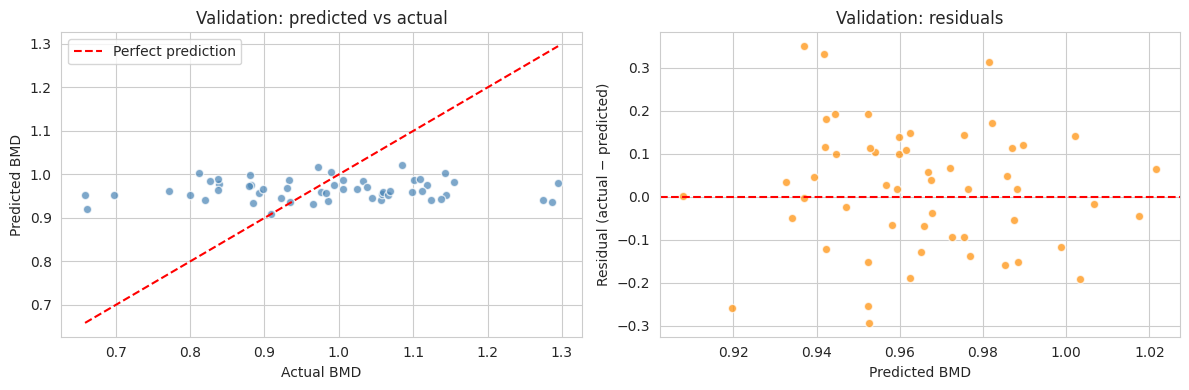

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual on validation
axes[0].scatter(y_val, y_pred_val, alpha=0.7, color="steelblue", edgecolor="white")
lo, hi = min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())
axes[0].plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual BMD")
axes[0].set_ylabel("Predicted BMD")
axes[0].set_title("Validation: predicted vs actual")
axes[0].legend()

# Residual plot
residuals = y_val - y_pred_val
axes[1].scatter(y_pred_val, residuals, alpha=0.7, color="darkorange", edgecolor="white")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted BMD")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Validation: residuals")

plt.tight_layout()
plt.show()

# 11 - Convert Predicted BMD

explain

nb: maybe remove this section?

In [34]:
# Convert predicted BMD into T-scores and binary labels
T_pred_val = (y_pred_val - REF_BMD) / REF_SD
label_pred_val = np.where(T_pred_val >= -1.0, 0, 1)

# True labels already exist from EDA
label_true_val = val_df["low_bmd"].values

results_df = pd.DataFrame({
    "filename": val_df["image"].values,
    "true_BMD": y_val.round(4),
    "pred_BMD": y_pred_val.round(4),
    "true_T": val_df["t_score"].values.round(3),
    "pred_T": T_pred_val.round(3),
    "true_label": label_true_val,
    "pred_label": label_pred_val,
})

results_df.head(15)

,filename,true_BMD,pred_BMD,true_T,pred_T,true_label,pred_label
0,6.E.1_9179238_20091120_001.png,1.1237,0.9423,2.197,0.686,False,0
1,6.E.1_9233869_20100505_001.png,0.8384,0.9770,-0.180,0.975,False,0
2,6.E.1_9254853_20100310_001.png,0.6587,0.9525,-1.677,0.771,True,0
3,6.C.1_9298541_20090401_001.png,1.1543,0.9821,2.453,1.017,False,0
4,6.C.1_9349019_20090420_001.png,1.1440,0.9523,2.367,0.769,False,0
5,6.E.1_9429578_20100426_001.png,0.8125,1.0034,-0.396,1.195,False,0
6,6.E.1_9435525_20090813_001.png,1.0244,0.9667,1.370,0.889,False,0
7,6.E.1_9973722_20090622_001.png,0.8814,0.9755,0.178,0.963,False,0
8,6.C.1_9041946_20090310_001.png,0.8853,0.9341,0.210,0.617,False,0
9,6.E.1_9093244_20090921_001.png,1.1187,0.9754,2.156,0.962,False,0


# 12 - Evaluation

explain

Confusion matrix (rows = true, cols = predicted):
    0  1
0  51  0
1   3  0

Sensitivity (Low BMD recall):  0.000
Specificity (Normal recall):   1.000
Balanced accuracy:             0.500

Full classification report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        51
           1       0.00      0.00      0.00         3

    accuracy                           0.94        54
   macro avg       0.47      0.50      0.49        54
weighted avg       0.89      0.94      0.92        54



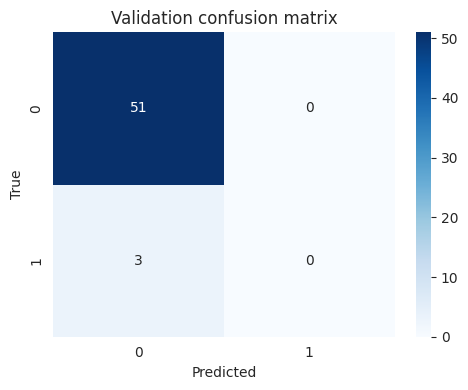

In [35]:
#Confusion Matrix

labels_order = [0, 1]
cm = confusion_matrix(label_true_val, label_pred_val, labels=labels_order)

# Print confusion matrix
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=labels_order, columns=labels_order))

# Sensitivity and specificity
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
specificity = TN / (TN + FP) if (TN + FP) > 0 else float("nan")
bal_acc     = balanced_accuracy_score(label_true_val, label_pred_val)

print(f"\nSensitivity (Low BMD recall):  {sensitivity:.3f}")
print(f"Specificity (Normal recall):   {specificity:.3f}")
print(f"Balanced accuracy:             {bal_acc:.3f}")

print("\nFull classification report:")
print(classification_report(label_true_val, label_pred_val, labels=labels_order, zero_division=0))

# Heatmap visualisation
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Validation confusion matrix")
plt.tight_layout(); plt.show()